In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as patches

import glob
import os
import logging
import datetime
import warnings
import re
import sys 
from skimage import io

from copy import deepcopy

# from matplotlib.colors import Normalize
from scipy.optimize import curve_fit

plt.rcParams['xtick.major.width'] = 1.8
plt.rcParams['axes.edgecolor'] = 'k'
plt.rcParams['errorbar.capsize'] = 5
plt.rcParams['lines.markersize'] = 4.

In [23]:
def func(x, a, b):
    return a * np.exp(-b * x)
def linear_func(x, a, b):
    return a * x + b

def quad_func(x, a, b, c):
    return a * x**2 + b * x + c

# Attempt 0: 10 data points:

[1.48564271e+03 1.12776731e-02]
[-0.0107348   3.57999832]


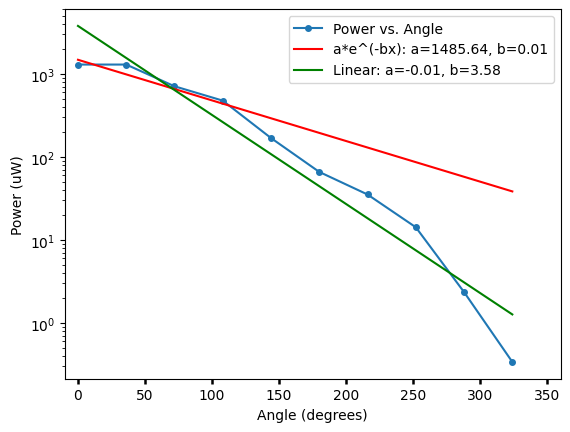

In [ ]:
data = [(0, 1300.8746),
        (36, 1300.8746),
        (72, 711.8479),
        (108, 477.8257),
        (144, 169.1549),
        (180, 66.0485),
        (216, 35.2933),
        (252, 14.2227),
        (288, 2.3516),
        (324, 0.3383)]

data_matrix = np.asarray(data)
angles = data_matrix[:,0]
power = data_matrix[:,1]
log_power = np.log10(power)

par, cov = curve_fit(func, *zip(*data), p0=(1200, 0.01))
parl, covl = curve_fit(linear_func, angles, log_power, p0=(-0.001, 0.01))

print(par)
print(parl)
plt.plot(*zip(*data), 'o-', label='Power vs. Angle')
plt.plot(angles, func(angles, *par), 'r-', label=f'a*e^(-bx): a={par[0]:.2f}, b={par[1]:.2f}')
plt.plot(angles, 10**linear_func(angles, *parl), 'g-', label=f'Linear: a={parl[0]:.2f}, b={parl[1]:.2f}')
plt.gca().set(xlabel='Angle (degrees)', ylabel='Power (uW)', xlim=(-10, 360), yscale='log')
plt.legend()

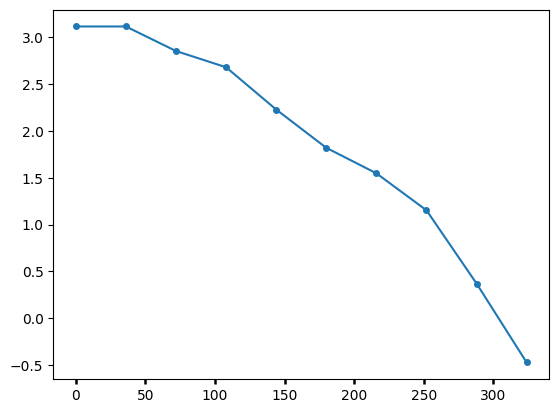

In [5]:
plt.plot(angles, log_power, 'o-', label='Log Power vs. Angle')

# Complete attempt:

- Measurement 1: 50 data points starting at 1.3 mW
- Measurement 2: 40 data points starting at 0.8 mW
- Measurement 3: 40 data points starting at 0.5 mW

In [165]:
data = pd.read_csv(r'G:\My Drive\Ba Tagging\results\ND_filter_characterization\power_ramp.csv')
data['power'] = sorted(data['power']*1e6, reverse=True)
# data['power'] = data['power'] / np.max(data['power'])

data2 = pd.read_csv(r'G:\My Drive\Ba Tagging\results\ND_filter_characterization\power_ramp2.csv')
data2['power'] = sorted(data2['power']*1e6, reverse=True)
# data2['power'] = data2['power'] / np.max(data2['power'])

data3 = pd.read_csv(r'G:\My Drive\Ba Tagging\results\ND_filter_characterization\power_ramp3.csv')
data3['power'] = sorted(data3['power']*1e6, reverse=True)
# data3['power'] = data3['power'] / np.max(data3['power'])
data3.head()

,angle,power
0,0.00,504.780270
1,9.23,485.253870
2,18.46,475.141336
3,27.69,469.772494
4,36.92,445.539219


In [166]:
data_matrix = np.asarray(data)
angles = data_matrix[:,0]
power = data_matrix[:,1]
log_power = np.log10(power)

data_matrix2 = np.asarray(data2)
angles2 = data_matrix2[:,0]
power2 = data_matrix2[:,1]
log_power2 = np.log10(power2)

data_matrix3 = np.asarray(data3)
angles3 = data_matrix3[:,0]
power3 = data_matrix3[:,1]
log_power3 = np.log10(power3)

par, cov = curve_fit(func, angles, power, p0=(1200, 0.01))    # Try simple exponential fit
parl, covl = curve_fit(linear_func, angles, log_power, p0=(-0.001, 0.01))  # Try linear fit to the log of the power
par2, cov2 = curve_fit(quad_func, angles, log_power, p0=(1, 1, 1))  # Try quadratic fit to the log of the power

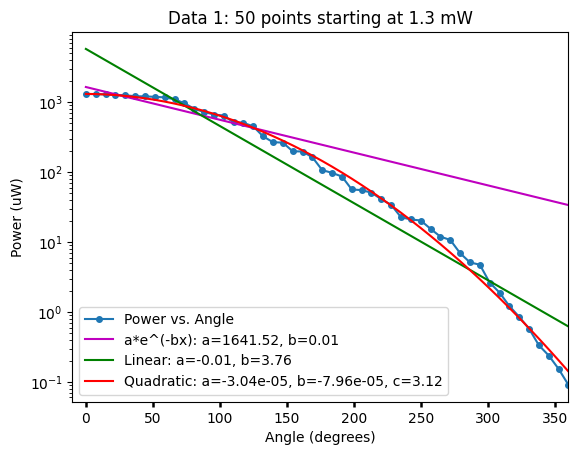

In [73]:
plt.plot(angles, power, 'o-', label='Power vs. Angle')
plt.plot(angles, func(angles, *par), 'm-', label=f'a*e^(-bx): a={par[0]:.2f}, b={par[1]:.2f}')
plt.plot(angles, 10**linear_func(angles, *parl), 'g-', label=f'Linear: a={parl[0]:.2f}, b={parl[1]:.2f}')
plt.plot(angles, 10**quad_func(angles, *par2), 'r-', label=f'Quadratic: a={par2[0]:.2e}, b={par2[1]:.2e}, c={par2[2]:.2f}')
plt.gca().set(xlabel='Angle (degrees)', ylabel='Power (uW)', xlim=(-10, 360), yscale='log', title = 'Data 1: 50 points starting at 1.3 mW')
plt.legend()

In [167]:
par22, cov22 = curve_fit(quad_func, angles2, log_power2, p0=(-3.038e-05, -7.96e-05,  1.042e-3))#, bounds=([-3.1e-5, -np.inf, 1.042e-3], [-3.0e-5, np.inf, 1.442e-3]))  # Stick with the quadratic fit for data 2 and 3
par23, cov23 = curve_fit(quad_func, angles3, log_power3, p0=(-3.038e-05, -7.96e-05, 1.042e-3))#, bounds=([-3.1e-5, -np.inf, 1.042e-3], [-3.0e-5, np.inf, 4.742e-3]))
# par23, cov23 = curve_fit(quad_func, angles3, log_power3, p0=(-3.038e-05, -7.96e-05, 3.116))#, bounds=([-3.1e-5, -np.inf, 3], [-3.0e-5, np.inf, 3.5]))

print(par2)
print(par22)
print(par23)

[-3.03889113e-05 -7.96063640e-05  3.11655392e+00]
[-2.10853734e-05 -2.81323558e-03  2.98771004e+00]
[-3.05828624e-05 -1.05567727e-04  2.67471273e+00]


In [181]:
par2[1], power[0] / power3[0] * par2[1], par23[1]

(-7.960636402266692e-05, -0.00020575753235748667, -0.00010556772745469959)

In [169]:
par22[0]/par2[0],  par22[1]/par2[1], 10**(0.86/1.3), par23[0]/par2[0], par23[1]/par2[1], 10**(0.5/1.3)

(0.6938508986766445,
 35.33933013351469,
 4.587102678234387,
 1.0063823011601893,
 1.3261217083679453,
 2.424462017082328)

In [164]:
par22[0]/par2[0],  par22[1]/par2[1], 10**(0.86/1.3), par23[0]/par2[0], par23[1]/par2[1], 10**(0.5/1.3)

(0.9872016083739743,
 2.030980448239198,
 4.587102678234387,
 0.9872016083743159,
 4.849528993777923,
 2.424462017082328)

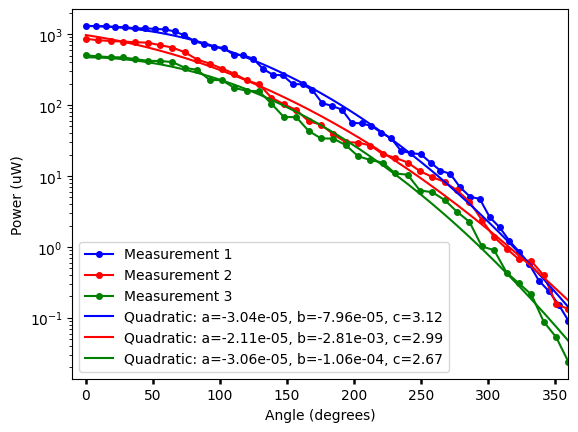

In [151]:
plt.plot(angles, power, 'bo-', label='Measurement 1')
plt.plot(angles2, power2, 'ro-', label='Measurement 2')
plt.plot(angles3, power3, 'go-', label='Measurement 3')
plt.plot(angles, 10**quad_func(angles, *par2), 'b-', label=f'Quadratic: a={par2[0]:.2e}, b={par2[1]:.2e}, c={par2[2]:.2f}')
plt.plot(angles2, 10**quad_func(angles2, *par22), 'r-', label=f'Quadratic: a={par22[0]:.2e}, b={par22[1]:.2e}, c={par22[2]:.2f}')
plt.plot(angles3, 10**quad_func(angles3, *par23), 'g-', label=f'Quadratic: a={par23[0]:.2e}, b={par23[1]:.2e}, c={par23[2]:.2f}')
plt.gca().set(xlabel='Angle (degrees)', ylabel='Power (uW)', xlim=(-10, 360), yscale='log')
plt.legend()

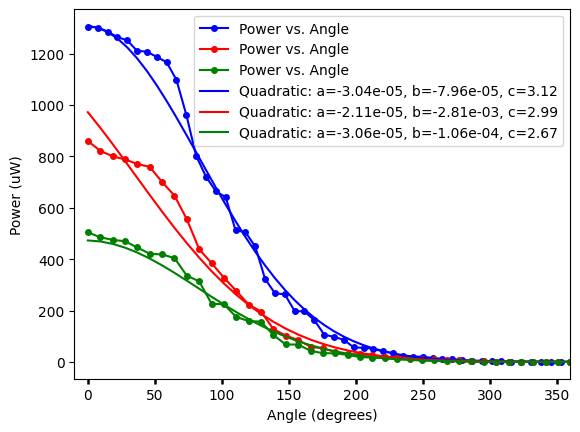

In [152]:
plt.plot(angles, power, 'bo-', label='Power vs. Angle')
plt.plot(angles2, power2, 'ro-', label='Power vs. Angle')
plt.plot(angles3, power3, 'go-', label='Power vs. Angle')

plt.plot(angles, 10**quad_func(angles, *par2), 'b-', label=f'Quadratic: a={par2[0]:.2e}, b={par2[1]:.2e}, c={par2[2]:.2f}')
plt.plot(angles2, 10**quad_func(angles2, *par22), 'r-', label=f'Quadratic: a={par22[0]:.2e}, b={par22[1]:.2e}, c={par22[2]:.2f}')
plt.plot(angles3, 10**quad_func(angles3, *par23), 'g-', label=f'Quadratic: a={par23[0]:.2e}, b={par23[1]:.2e}, c={par23[2]:.2f}')
plt.gca().set(xlabel='Angle (degrees)', ylabel='Power (uW)', xlim=(-10, 360),)
plt.legend()

In [71]:
pardf = pd.DataFrame({'a': [par2[0], par22[0], par23[0]], 'b': [par2[1], par22[1], par23[1]], 'c': [par2[2], par22[2], par23[2]]})
pardf

,a,b,c
0,-0.000030,-0.000080,3.116554
1,-0.000021,-0.002813,2.987710
2,-0.000031,-0.000106,2.674712
